# Validation against Xu & Froment (1989, Part II) Fig. 3

Digitised curves of Fig. 3 (p. 101) are compared with the 1-D tube model (`rdt.reactor1d`) using the digitised
outer-wall temperature as boundary condition over the heated length (0-11.12 m) and an adiabatic tail to 12 m.

Part 1 (Leva-Grummer heat transfer): two-stage bounded least-squares calibration, (A) bed voidage and particle
diameter on the pressure curve, (B) one effectiveness-factor multiplier on `x_CH4` and `T_gas`; Latham's inlet
variant; an `f_htg` diagnostic sweep.

Part 2 (Xu & Froment heat-transfer chain, Part II Eqs. 11-12 with Kunii-Smith static conductivity): four
combinations {leva_grummer, xu_froment} x {latham, xu_froment inlet definition} with the stage-A bed and eta = 0.1,
no fitting. Temperature metrics exclude z < 0.3 m because the digitised `T_gas` starts at 764 K while Table 2 gives
793.15 K. The bed-side coefficient implied by the digitised curves is back-calculated for comparison.

All results go to `data/literature_validation/xf1989_fit.yaml`. The left-axis correction `x = raw*(1+zeta)`,
zeta = 0.056, is an assumption to be confirmed by the chemical engineer, as is the conversion definition at z = 0.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

from rdt import validate_xf1989 as vx

tidy = vx.load_tidy()
cv = vx.curves(tidy)
print("rows per curve:", tidy.groupby("curve").size().to_dict())
print("\nSanity checks on the digitised data")
sanity = vx.sanity_checks(tidy)
for k, (v, (lo, hi), ok) in sanity.items():
    print(f"  {k:18s} = {v:9.3f}   expected {lo}-{hi}   {'OK' if ok else 'FLAG'}")
for c in ("T_gas", "T_wall_inner", "x_CH4", "x_CO2"):
    z, v = cv[c]; print(f"  {c:13s} first digitised point z={z[0]:.3f}: {v[0]:.4f}")
print("  Table 2 inlet T0 = 793.15 K; digitised T_gas starts ~29 K lower. Conversions start at ~0.06, not 0.")

def show(m):
    for c, d in m.items():
        print(f"   {c:13s} RMSE = {d['rmse']:8.4f} {d['unit']:3s}  max|err| = {d['max_abs']:8.4f}  bias = {d['mean_bias']:+8.4f}  (n={d['n']})")


rows per curve: {'T_gas': 386, 'T_wall_inner': 261, 'T_wall_outer': 118, 'p_t': 462, 'x_CH4': 457, 'x_CO2': 422}

Sanity checks on the digitised data
  T_wall_outer_z0    =  1012.877   expected 1000.0-1040.0   OK
  T_wall_outer_max   =  1176.215   expected 1160.0-1190.0   OK
  p_t_z0             =    28.959   expected 28.5-29.5   OK
  p_t_z11.5          =    25.761   expected 25.0-26.0   OK
  x_CH4_z11.12       =     0.589   expected 0.55-0.65   OK
  T_gas         first digitised point z=0.009: 763.9571
  T_wall_inner  first digitised point z=0.005: 984.3139
  x_CH4         first digitised point z=0.008: 0.0601
  x_CO2         first digitised point z=0.011: 0.0581
  Table 2 inlet T0 = 793.15 K; digitised T_gas starts ~29 K lower. Conversions start at ~0.06, not 0.


In [2]:
# ---- Part 1: Leva-Grummer, calibration (as before) -------------------------------------
wall = vx.wall_from_digitised(tidy)
BASE_VOID, BASE_DP = 0.6, 9.24e-3
base = vx.run(BASE_VOID, BASE_DP, wall); m_base = vx.metrics(base, cv); out_base = vx.outlet_summary(base)
print("BASELINE (voidage 0.6, d_p 9.24 mm, eta 0.1):"); show(m_base)
A = vx.calibrate_stage_a(cv, wall)
B = vx.calibrate_stage_b(cv, wall, A["voidage"], A["d_p_m"])
fit = vx.run(A["voidage"], A["d_p_m"], wall, eta=vx.eta_spec(B["eta_multiplier"])); m_fit = vx.metrics(fit, cv); out_fit = vx.outlet_summary(fit)
print(f"\nStage A: voidage {A['voidage']:.4f}, d_p {1e3*A['d_p_m']:.3f} mm ({A['n_runs']} runs); Stage B: eta multiplier {B['eta_multiplier']:.3f} (at bound: {B['at_bound']})")
print("FITTED:"); show(m_fit)
BL = vx.calibrate_stage_b(cv, wall, A["voidage"], A["d_p_m"], latham=True)
fitL = vx.run(A["voidage"], A["d_p_m"], wall, eta=vx.eta_spec(BL["eta_multiplier"], latham=True)); m_fitL = vx.metrics(fitL, cv); out_fitL = vx.outlet_summary(fitL)
lat_base = vx.run(BASE_VOID, BASE_DP, wall, eta=vx.eta_spec(1.0, latham=True))
print(f"\nLatham inlet variant: inlet dip {out_base['inlet_dip_K']:.1f} K -> {vx.outlet_summary(lat_base)['inlet_dip_K']:.1f} K (baseline bed), {out_fitL['inlet_dip_K']:.1f} K (fitted)")
diag = {}
for f in (1.0, 0.7, 0.5, 0.4, 0.3):
    r = vx.run(A["voidage"], A["d_p_m"], wall, eta=vx.eta_spec(1.0), f_htg=f); m = vx.metrics(r, cv)
    diag[f] = {"T_gas_rmse": m["T_gas"]["rmse"], "T_gas_bias": m["T_gas"]["mean_bias"], "x_CH4_rmse": m["x_CH4"]["rmse"],
               "x_CH4_bias": m["x_CH4"]["mean_bias"], "T_wall_inner_rmse": m["T_wall_inner"]["rmse"],
               "conversion_at_11.12": float(np.interp(11.12, r.z, r.conversion_CH4)), "T_at_11.12": float(np.interp(11.12, r.z, r.T))}
print("\nf_htg diagnostic (eta 0.1, stage-A bed):")
for f, d in diag.items(): print(f"   f_htg={f:.1f}: RMSE T_gas {d['T_gas_rmse']:6.1f} K, RMSE x_CH4 {d['x_CH4_rmse']:.3f}")


BASELINE (voidage 0.6, d_p 9.24 mm, eta 0.1):
   x_CH4         RMSE =   0.1465 -    max|err| =   0.2031  bias =  +0.1241  (n=457)
   x_CO2         RMSE =   0.0300 -    max|err| =   0.0532  bias =  +0.0011  (n=422)
   T_gas         RMSE =  73.2598 K    max|err| =  92.2462  bias = +70.3359  (n=386)
   T_wall_inner  RMSE =  37.7032 K    max|err| =  92.2399  bias =  -2.3633  (n=261)
   p_t           RMSE =   0.6991 bar  max|err| =   1.5031  bias =  +0.5501  (n=462)



Stage A: voidage 0.5261, d_p 9.440 mm (74 runs); Stage B: eta multiplier 0.200 (at bound: True)
FITTED:
   x_CH4         RMSE =   0.1164 -    max|err| =   0.1723  bias =  +0.0862  (n=457)
   x_CO2         RMSE =   0.0260 -    max|err| =   0.0561  bias =  -0.0150  (n=422)
   T_gas         RMSE =  75.0836 K    max|err| =  82.5078  bias = +73.8056  (n=386)
   T_wall_inner  RMSE =  34.4461 K    max|err| =  85.2650  bias =  -2.1548  (n=261)
   p_t           RMSE =   0.0505 bar  max|err| =   0.1447  bias =  +0.0022  (n=462)



Latham inlet variant: inlet dip 15.9 K -> 8.5 K (baseline bed), 0.0 K (fitted)



f_htg diagnostic (eta 0.1, stage-A bed):
   f_htg=1.0: RMSE T_gas   73.1 K, RMSE x_CH4 0.153
   f_htg=0.7: RMSE T_gas   51.3 K, RMSE x_CH4 0.105
   f_htg=0.5: RMSE T_gas   27.6 K, RMSE x_CH4 0.054
   f_htg=0.4: RMSE T_gas   10.8 K, RMSE x_CH4 0.023
   f_htg=0.3: RMSE T_gas   13.5 K, RMSE x_CH4 0.044


In [3]:
# ---- Part 2: Xu & Froment heat-transfer chain, four combinations, no fitting ------------
combos = vx.four_combinations(cv, wall)
print(f"Stage-A bed: voidage {vx.STAGE_A_BED['voidage']}, d_p {1e3*vx.STAGE_A_BED['d_p_m']:.2f} mm; eta = 0.1; temperatures compared for z >= {vx.Z_MIN_TEMPERATURE} m\n")
hdr = f"{'combination':32s} {'inlet x':>8s} {'film dT0':>9s} {'alpha_i(0)':>10s} | {'x_CH4':>13s} | {'x_CO2':>13s} | {'T_gas':>15s} | {'T_wi':>15s} | {'p_t':>13s} | conv@11.12 T@11.12"
print(hdr); print("-" * len(hdr))
for k, d in combos.items():
    m = d["metrics"]; o = d["outlet"]
    def f(c, w=6, p=3): return f"{m[c]['rmse']:{w}.{p}f}/{m[c]['mean_bias']:+{w}.{p}f}"
    print(f"{k:32s} {d['inlet_conversion']:8.4f} {d['inlet_film_dT_K']:9.1f} {d['alpha_i_W_m2K']['inlet']:10.0f} | {f('x_CH4')} | {f('x_CO2')} | {f('T_gas',7,1)} | {f('T_wall_inner',7,1)} | {f('p_t')} | {o['conversion_CH4_at_11.12']:.3f}   {o['T_K_at_11.12']:.0f}")
print("(RMSE / bias; K for temperatures, bar for p_t)")

bc = vx.alpha_i_from_digitised(cv)
print("\nBed-side coefficient back-calculated from the digitised Fig. 3 (lambda_tube = 29.6 W/mK assumed):")
for i in range(len(bc["z_m"])):
    print(f"   z={bc['z_m'][i]:5.1f} m  T_wo={bc['T_wo'][i]:6.1f} T_wi={bc['T_wi'][i]:6.1f} T_gas={bc['T_gas'][i]:6.1f}  q_o={bc['q_o_kW_m2'][i]:5.1f} kW/m2  alpha_i={bc['alpha_i_W_m2K'][i]:6.0f} W/m2K")
best = {ht: min((k for k in combos if k.startswith(ht)), key=lambda k: combos[k]["metrics"]["x_CH4"]["rmse"]) for ht in ("leva_grummer", "xu_froment")}
print("\nbest inlet definition per correlation (lowest x_CH4 RMSE):", best)


Stage-A bed: voidage 0.526, d_p 9.44 mm; eta = 0.1; temperatures compared for z >= 0.3 m

combination                       inlet x  film dT0 alpha_i(0) |         x_CH4 |         x_CO2 |           T_gas |            T_wi |           p_t | conv@11.12 T@11.12
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
leva_grummer__inlet_latham         0.0175     154.1        941 |  0.160/+0.140 |  0.034/+0.010 |    75.4/  +73.4 |    37.5/   -0.9 |  0.045/-0.005 | 0.801   1114
leva_grummer__inlet_xu_froment     0.0914     151.4        999 |  0.172/+0.161 |  0.041/+0.018 |    83.2/  +82.5 |    36.6/   +1.7 |  0.057/-0.036 | 0.805   1116
xu_froment__inlet_latham           0.0175      91.6       3094 |  0.240/+0.222 |  0.054/+0.020 |   114.4/ +113.0 |    50.7/   +1.5 |  0.129/-0.109 | 0.862   1144
xu_froment__inlet_xu_froment       0.0914      91.2       3114 |  0.247/+0.235 |  0.059/

In [4]:
# ---- Part 3: verification with a matched (back-calculated) film coefficient --------------
V = vx.verification_runs(cv, wall)
prof = V["alpha_profile"]
print(f"alpha_i back-calculated from digitised Fig. 3 over 0.5-11 m (lambda_tube = {prof['lambda_tube']:.1f} W/mK): "
      f"median {prof['median']:.0f} W/m2K, IQR {prof['q25']:.0f}-{prof['q75']:.0f} ({prof['iqr']:.0f}), range {prof['min']:.0f}-{prof['max']:.0f}")
hdr = f"{'run':44s} {'film dT0':>8s} | {'x_CH4':>13s} | {'x_CO2':>13s} | {'T_gas':>15s} | {'T_wi':>15s} | {'p_t':>13s} | {'x incr':>13s} | conv@11.12 T@11.12"
print("\n" + hdr); print("-" * len(hdr))
for k, d in V["runs"].items():
    m = d["metrics"]; inc = d["x_CH4_increment"]; o = d["outlet"]
    def f(c, w=6, p=3): return f"{m[c]['rmse']:{w}.{p}f}/{m[c]['mean_bias']:+{w}.{p}f}"
    print(f"{k:44s} {d['inlet_film_dT_K']:8.0f} | {f('x_CH4')} | {f('x_CO2')} | {f('T_gas',7,1)} | {f('T_wall_inner',7,1)} | {f('p_t')} | {inc['rmse']:6.3f}/{inc['mean_bias']:+6.3f} | {o['conversion_CH4_at_11.12']:.3f}   {o['T_K_at_11.12']:.0f}")
print("(RMSE / bias; temperatures z >= 0.3 m; x incr = x_CH4(z) - x_CH4(0.5 m) for z >= 0.5 m)")
print("\nrecommended verification configuration:", V["recommended"], "(score = RMSE T_gas [K] + 1000 RMSE increment)")
# misprint hypotheses evaluated at inlet conditions
import cantera as ct
from rdt import reactor1d as r1
_tube = r1.tube_from_xu_froment(); _F = r1.feed_from_xu_froment().state_flows(); _gas = ct.Solution("gri30.yaml")
_X = {s: v / sum(_F.values()) for s, v in _F.items()}; _mw = {s: _gas.molecular_weights[_gas.species_index(s)] for s in _F}
_G = sum(_F[s] * _mw[s] for s in _F) / 3600 / _tube.A_cs
hyp = {}
for T in (793.15, 1000.0):
    _gas.TPX = T, 29e5, _X; lg, mu, cp = _gas.thermal_conductivity, _gas.viscosity, _gas.cp_mass
    lam0 = r1.kunii_smith_lambda_er0(lg, 1.0, vx.STAGE_A_BED["voidage"], T, 0.8, vx.STAGE_A_BED["d_p_m"])
    Re = vx.STAGE_A_BED["d_p_m"] * _G / mu; Pr = cp * mu / lg
    aw0 = r1.xu_froment_alpha_i(lg, mu, cp, _G, vx.STAGE_A_BED["d_p_m"], _tube.d_i, lam0)["alpha_w0"]
    def ai(cw, cl):
        aw = aw0 + cw * Re * Pr * lg / vx.STAGE_A_BED["d_p_m"]; le = lam0 + cl * lg * Re * Pr
        return 8 * le * aw / (8 * le + aw * _tube.d_i)
    hyp[f"{T:.0f}K"] = {"Re": Re, "Pr": Pr, "lam_er0": lam0, "printed_0.444_0.14": ai(0.444, 0.14),
                        "hyp_0.0444_0.14": ai(0.0444, 0.14), "hyp_0.444_0.014": ai(0.444, 0.014), "static_only": ai(0, 0)}
    print(f"T={T:.0f} K: Re={Re:.0f}, Pr={Pr:.3f}, lam_er0={lam0:.2f} W/mK | alpha_i printed {ai(0.444,0.14):.0f} | 0.0444 hyp {ai(0.0444,0.14):.0f} | 0.014 hyp {ai(0.444,0.014):.0f} | static only {ai(0,0):.0f} W/m2K")


alpha_i back-calculated from digitised Fig. 3 over 0.5-11 m (lambda_tube = 29.6 W/mK): median 348 W/m2K, IQR 313-363 (49), range 299-378

run                                          film dT0 |         x_CH4 |         x_CO2 |           T_gas |            T_wi |           p_t |        x incr | conv@11.12 T@11.12
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
alpha_const_median__eta_0.1                       190 |  0.037/-0.034 |  0.031/-0.031 |    13.7/  -11.4 |    16.7/   -4.7 |  0.248/+0.168 |  0.020/-0.013 | 0.528   1005
alpha_const_median__eta_latham_inlet              190 |  0.039/-0.037 |  0.033/-0.032 |    14.0/  -11.1 |    16.7/   -4.8 |  0.248/+0.168 |  0.015/-0.005 | 0.527   1005
alpha_profile_pchip__eta_0.1                      194 |  0.044/-0.042 |  0.035/-0.035 |    17.4/  -16.5 |    16.8/   -4.7 |  0.261/+0.180 |  0.023/-0.019 | 0.526   1004
alpha

saved /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig03_validation_xf1989.png


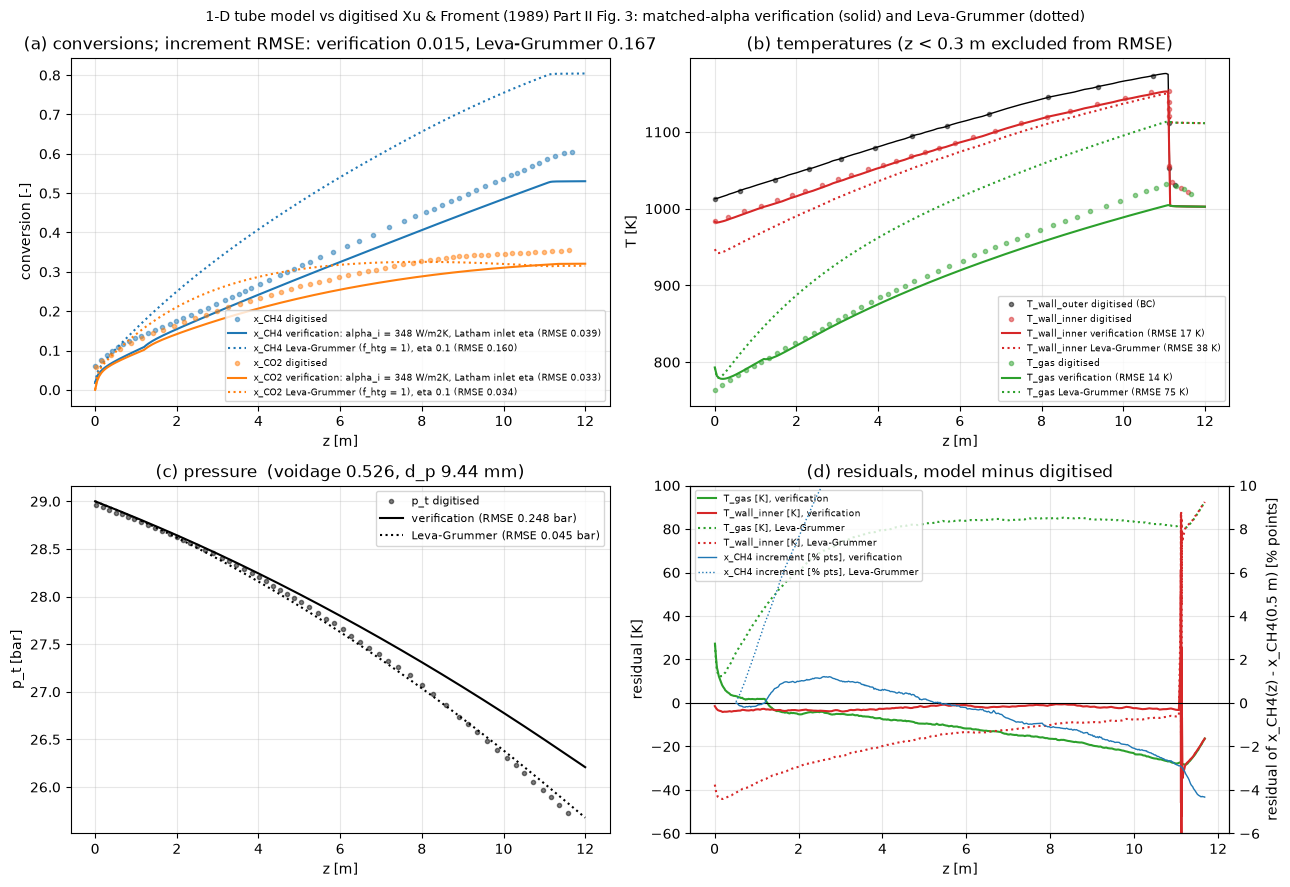

In [5]:
REC = V["runs"][V["recommended"]]["result"]; mREC = V["runs"][V["recommended"]]["metrics"]; incREC = V["runs"][V["recommended"]]["x_CH4_increment"]
LG = combos["leva_grummer__inlet_latham"]["result"]; mLG = combos["leva_grummer__inlet_latham"]["metrics"]; incLG = vx.increment_metric(LG, cv)
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
mk = dict(ls="none", marker="o", ms=3, alpha=0.5); sub = 8
def data(c): z, v = cv[c]; return z[::sub], v[::sub]
lab_rec = f"verification: alpha_i = {prof['median']:.0f} W/m2K, Latham inlet eta"
lab_lg = "Leva-Grummer (f_htg = 1), eta 0.1"

a = ax[0, 0]
for c, col in (("x_CH4", "C0"), ("x_CO2", "C1")):
    z, v = data(c); a.plot(z, v, color=col, label=f"{c} digitised", **mk)
    a.plot(REC.z, vx.model_curve(REC, c, REC.z), color=col, ls="-", label=f"{c} {lab_rec} (RMSE {mREC[c]['rmse']:.3f})")
    a.plot(LG.z, vx.model_curve(LG, c, LG.z), color=col, ls=":", label=f"{c} {lab_lg} (RMSE {mLG[c]['rmse']:.3f})")
a.set_xlabel("z [m]"); a.set_ylabel("conversion [-]"); a.set_title(f"(a) conversions; increment RMSE: verification {incREC['rmse']:.3f}, Leva-Grummer {incLG['rmse']:.3f}"); a.grid(alpha=0.3); a.legend(fontsize=6.5)

b = ax[0, 1]
z, v = data("T_wall_outer"); b.plot(z, v, color="k", label="T_wall_outer digitised (BC)", **mk); b.plot(REC.z, REC.T_wall_outer, color="k", lw=1)
for c, col in (("T_wall_inner", "C3"), ("T_gas", "C2")):
    z, v = data(c); b.plot(z, v, color=col, label=f"{c} digitised", **mk)
    b.plot(REC.z, vx.model_curve(REC, c, REC.z), color=col, ls="-", label=f"{c} verification (RMSE {mREC[c]['rmse']:.0f} K)")
    b.plot(LG.z, vx.model_curve(LG, c, LG.z), color=col, ls=":", label=f"{c} Leva-Grummer (RMSE {mLG[c]['rmse']:.0f} K)")
b.set_xlabel("z [m]"); b.set_ylabel("T [K]"); b.set_title("(b) temperatures (z < 0.3 m excluded from RMSE)"); b.grid(alpha=0.3); b.legend(fontsize=6.5)

c_ = ax[1, 0]
z, v = data("p_t"); c_.plot(z, v, color="k", label="p_t digitised", **mk)
c_.plot(REC.z, REC.P, "k-", label=f"verification (RMSE {mREC['p_t']['rmse']:.3f} bar)")
c_.plot(LG.z, LG.P, "k:", label=f"Leva-Grummer (RMSE {mLG['p_t']['rmse']:.3f} bar)")
c_.set_xlabel("z [m]"); c_.set_ylabel("p_t [bar]"); c_.set_title(f"(c) pressure  (voidage {vx.STAGE_A_BED['voidage']}, d_p {1e3*vx.STAGE_A_BED['d_p_m']:.2f} mm)"); c_.grid(alpha=0.3); c_.legend(fontsize=8)

d = ax[1, 1]
for res, ls, lab in ((REC, "-", "verification"), (LG, ":", "Leva-Grummer")):
    z, v = cv["T_gas"]; d.plot(z, vx.model_curve(res, "T_gas", z) - v, color="C2", ls=ls, label=f"T_gas [K], {lab}")
    z, v = cv["T_wall_inner"]; d.plot(z, vx.model_curve(res, "T_wall_inner", z) - v, color="C3", ls=ls, label=f"T_wall_inner [K], {lab}")
d.axhline(0, color="k", lw=0.8); d.set_xlabel("z [m]"); d.set_ylabel("residual [K]"); d.set_ylim(-60, 100)
d2 = d.twinx()
zx, vxr = cv["x_CH4"]; mz = zx >= 0.5
for res, ls, lab in ((REC, "-", "verification"), (LG, ":", "Leva-Grummer")):
    inc_m = vx.model_curve(res, "x_CH4", zx[mz]) - np.interp(0.5, res.z, res.conversion_CH4)
    inc_d = vxr[mz] - np.interp(0.5, zx, vxr)
    d2.plot(zx[mz], 100 * (inc_m - inc_d), color="C0", ls=ls, lw=1, label=f"x_CH4 increment [% pts], {lab}")
d2.set_ylabel("residual of x_CH4(z) - x_CH4(0.5 m) [% points]"); d2.set_ylim(-6, 10)
h1, l1 = d.get_legend_handles_labels(); h2, l2 = d2.get_legend_handles_labels(); d.legend(h1 + h2, l1 + l2, fontsize=6.5, loc="upper left")
d.set_title("(d) residuals, model minus digitised"); d.grid(alpha=0.3)
fig.suptitle("1-D tube model vs digitised Xu & Froment (1989) Part II Fig. 3: matched-alpha verification (solid) and Leva-Grummer (dotted)", fontsize=10)
fig.tight_layout()
out = Path("..") / "paper" / "figures" / "fig03_validation_xf1989.png"
fig.savefig(out, dpi=150); print("saved", out.resolve()); plt.show()


In [6]:
def py(o):
    if isinstance(o, dict): return {str(k): py(v) for k, v in o.items() if k != "result"}
    if isinstance(o, (list, tuple)): return [py(v) for v in o]
    if isinstance(o, (np.floating, np.integer)): return o.item()
    if isinstance(o, np.bool_): return bool(o)
    return o

doc = {
    "source": "Xu & Froment (1989) Part II, AIChE J. 35:97-103, Fig. 3 (p. 101), digitised with WebPlotDigitizer",
    "data_file": "data/literature_validation/digitized/xf1989_fig3_tidy.csv",
    "data_notes": [
        "conversion curves corrected by (1+zeta), zeta = CO2/CH4 = 0.056 (ASSUMPTION, to be confirmed)",
        "digitised T_gas starts at ~764 K at z~0 although Table 2 gives T0 = 793.15 K (not corrected)",
        "digitised conversions start at ~0.06 at z~0, not at 0 (not corrected)",
        "T_wall_outer beyond 11.12 m falls to the gas temperature: tail treated as adiabatic",
    ],
    "sanity_checks": py({k: {"value": v, "range": list(r), "ok": ok} for k, (v, r, ok) in sanity.items()}),
    "boundary_condition": "PCHIP of digitised T_wall_outer for 0 <= z <= 11.12 m; adiabatic (U = 0) for 11.12 < z <= 12 m",
    "compared_on": "digitised z grid of each curve (model interpolated linearly onto it)",
    "leva_grummer": {
        "description": "Leva-Grummer bed-side coefficient (Latham 2011 Eq. 20), all 5.168 kmol/h fed as CH4, Latham inlet rule",
        "objective_definition": (
            "least_squares (scipy, trf, bounded) on residuals r_c(z_k) = (model - data)/(max(data_c) - min(data_c))/sqrt(n_c) "
            "for each compared curve c on its digitised grid; stage A: c in {p_t}, parameters voidage in [0.35, 0.60], d_p in [4, 12] mm; "
            "stage B: c in {x_CH4, T_gas}, parameter m in [0.2, 2.0] with eta_1 = eta_2 = eta_3 = 0.1 m, stage-A values fixed"),
        "baseline": {"parameters": {"voidage": BASE_VOID, "d_p_m": BASE_DP, "eta": [0.1, 0.1, 0.1], "f_htg": 1.0}, "metrics": py(m_base), "outlet": py(out_base)},
        "fitted": {"stage_A": py(A), "stage_B": py(B), "parameters": {"voidage": A["voidage"], "d_p_m": A["d_p_m"], "eta": B["eta_values"], "f_htg": 1.0},
                   "metrics": py(m_fit), "outlet": py(out_fit)},
        "latham_inlet_variant": {"description": "eta = 0.05*m for z < 1.2 m (10 % of 12 m), 0.1*m elsewhere", "stage_B": py(BL), "metrics": py(m_fitL),
                                 "outlet": py(out_fitL), "inlet_dip_K_baseline_bed_eta0.1": py(out_base["inlet_dip_K"]),
                                 "inlet_dip_K_baseline_bed_latham": py(vx.outlet_summary(lat_base)["inlet_dip_K"]), "removes_inlet_dip": bool(out_fitL["inlet_dip_K"] < 0.5)},
        "diagnostics_f_htg_sweep": {"description": "stage-A bed, eta = 0.1, Leva-Grummer multiplier f_htg varied (not fitted)", "results": py({str(k): v for k, v in diag.items()})},
    },
    "xu_froment_correlation": {
        "description": ("Xu & Froment Part II Eqs. 11-12 as printed, SI: alpha_w = alpha_w0 + 0.444 Re Pr lam_g/d_p, "
                        "alpha_w0 = 8.694 lam_er0/d_ti^(4/3), lam_er = lam_er0 + 0.14 lam_g Re Pr, alpha_i = 8 lam_er alpha_w/(8 lam_er + alpha_w d_ti), "
                        "lam_er0 from Kunii & Smith (1960) with lambda_s = 1.0 W/(m K) and emissivity 0.8 (assumed); no fitted multipliers"),
        "bed": {"voidage": vx.STAGE_A_BED["voidage"], "d_p_m": vx.STAGE_A_BED["d_p_m"], "eta": [0.1, 0.1, 0.1], "source": "stage A of the Leva-Grummer calibration"},
        "feed": "Table 2 equivalent CH4 split into CH4/C2H6/C3H8/C4H10/C5H12 by the natural-gas carbon fractions; inlet rule as labelled",
        "temperature_comparison": f"z >= {vx.Z_MIN_TEMPERATURE} m only (digitised T_gas starts at 764 K vs Table 2 T0 = 793.15 K)",
        "combinations": py(combos),
        "best_inlet_definition_by_x_CH4_rmse": best,
        "alpha_i_back_calculated_from_digitised": {"method": "q_o = (T_wo - T_wi) 2 lambda_tube/(d_o ln(d_o/d_i)); q_i = q_o d_o/d_i; alpha_i = q_i/(T_wi - T_gas); lambda_tube = 29.6 W/(m K) assumed (not given by Xu & Froment)",
                                                  "values": py(bc)},
        "finding": ("The correlations as printed give alpha_i ~ 3100-3700 W/(m2 K), about 3x Leva-Grummer and ~10x the 300-370 W/(m2 K) "
                    "implied by the digitised Fig. 3 curves; they therefore make the gas hotter and conversion higher than the paper's own results. "
                    "Neither combination meets RMSE(T_gas) < 15 K and RMSE(x_CH4) < 0.03. To be discussed with the chemical engineer (units of lam_g, Re definition)."),
    },
}
doc["verification_matched_alpha"] = {
    "description": ("1-D model with a prescribed bed-side coefficient back-calculated from the digitised Fig. 3 "
                    "(wall conduction from T_wall_outer - T_wall_inner with lambda_tube = 29.6 W/(m K), then q_i/(T_wall_inner - T_gas)); "
                    "feed, digitised outer wall, stage-A bed; no fitting"),
    "alpha_i_back_calculated": {"z_range_m": [0.5, 11.0], "median_W_m2K": prof["median"], "q25": prof["q25"], "q75": prof["q75"],
                                "iqr": prof["iqr"], "min": prof["min"], "max": prof["max"], "lambda_tube_W_mK": prof["lambda_tube"],
                                "profile": {"z_m": py(list(prof["z"])), "alpha_i_W_m2K": py(list(prof["alpha_i"]))}},
    "increment_metric": f"RMSE/bias of x_CH4(z) - x_CH4({vx.Z_INCREMENT_REF} m) for z >= {vx.Z_INCREMENT_REF} m (removes the inlet-definition ambiguity)",
    "runs": py(V["runs"]),
    "score": py(V["score"]),
    "recommended_configuration": V["recommended"],
    "recommended_description": f"heat_transfer='constant', alpha_i = {prof['median']:.0f} W/(m2 K); eta = 0.05 for z < 1.2 m, 0.1 elsewhere; stage-A bed; Latham inlet rule",
    "misprint_hypotheses_alpha_i_at_inlet": py(hyp),
    "decision": ("Xu & Froment case = verification with matched alpha_i; Latham plant data = validation of alpha_i; "
                 "alpha_i range [300, 3000] W/(m2 K) carried into the uncertainty analysis (see paper/notes/heat_transfer_discrepancy.md)"),
}
with open(Path("..") / "data" / "literature_validation" / "xf1989_fit.yaml", "w") as f:
    yaml.safe_dump(doc, f, sort_keys=False, default_flow_style=False, width=130)
print("wrote xf1989_fit.yaml")


wrote xf1989_fit.yaml
